RESULTADOS

Figura 1 — Circulo
  Vertices    : 2
  Area        : 23402.0 px2
  Circularidad: 0.004
  Momentos de Hu:
    Hu[1] = 1.064106e+00
    Hu[2] = 7.948361e-01
    Hu[3] = 4.154668e-01
    Hu[4] = 4.010170e-01
    Hu[5] = 1.636720e-01
    Hu[6] = 3.570011e-01
    Hu[7] = -2.160111e-03

Figura 2 — Circulo
  Vertices    : 2
  Area        : 29387.0 px2
  Circularidad: 0.008
  Momentos de Hu:
    Hu[1] = 5.577862e-01
    Hu[2] = 8.179186e-02
    Hu[3] = 1.056271e-01
    Hu[4] = 8.177976e-02
    Hu[5] = 7.375959e-03
    Hu[6] = 2.337112e-02
    Hu[7] = 1.834832e-03

Figura 3 — Triangulo
  Vertices    : 3
  Area        : 11180.5 px2
  Circularidad: 0.103
  Momentos de Hu:
    Hu[1] = 2.624295e-01
    Hu[2] = 3.121378e-02
    Hu[3] = 3.266036e-03
    Hu[4] = 3.106557e-04
    Hu[5] = -3.124506e-07
    Hu[6] = -5.428746e-05
    Hu[7] = 1.708279e-08

Figura 4 — Triangulo
  Vertices    : 3
  Area        : 14422.5 px2
  Circularidad: 0.024
  Momentos de Hu:
    Hu[1] = 3.119262e-01
    Hu[2

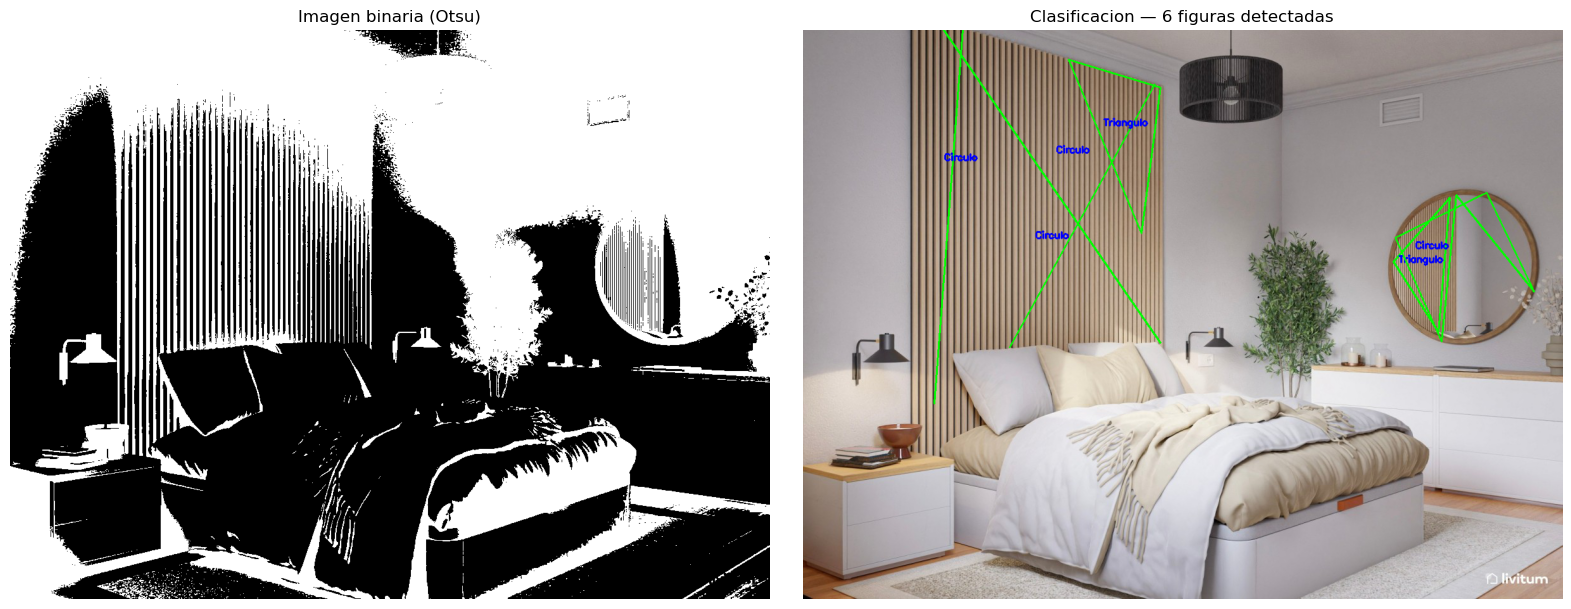

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#geo2.jpg
#geo3.jpg
#geo.webp
imagen = cv2.imread("pai1.jpg")

if imagen is None:
    # Imagen sintetica de prueba
    imagen = np.ones((500, 620, 3), np.uint8) * 245
    cv2.circle(imagen,    ( 90,  90),  65, ( 50,  50, 220), -1)
    cv2.fillPoly(imagen,  [np.array([[265,25],[180,160],[350,160]])], ( 40,190, 40))
    cv2.rectangle(imagen, (380,  25), (510, 155), (220, 50,  50), -1)
    cv2.rectangle(imagen, ( 30, 250), (120, 420), ( 30,120, 180), -1)
    cv2.ellipse(imagen,   (305, 350), (140,  78), 0, 0, 360, (220,150, 20), -1)
    cv2.fillPoly(imagen,  [np.array([[470,250],[400,400],[540,400]])], (170, 25,170))
    print("geo.webp no encontrado — usando imagen sintetica")

# 2. ESCALA DE GRISES Y BINARIA (Otsu)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, binaria = cv2.threshold(
    gris, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# 3. SEGMENTACION POR COLOR HSV
#
# La binarizacion simple fusiona figuras
# adyacentes en un solo contorno.
# Cuantizar el espacio HSV y separar por
# componentes conectados da un contorno
# independiente a cada figura, incluso
# cuando se tocan.
def obtener_contornos_por_color(bgr, sat_min=60, step_h=15, step_s=80, min_area_pct=0.008):
    h, w   = bgr.shape[:2]
    min_area = h * w * min_area_pct

    hsv      = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h_q      = (hsv[:,:,0] // step_h * step_h).astype(np.int32)
    s_q      = (hsv[:,:,1] // step_s * step_s).astype(np.int32)
    color_id = h_q * 256 + s_q
    color_id[hsv[:,:,1] < sat_min] = -1   # excluir fondo (baja saturacion)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    contornos = []

    for uid in np.unique(color_id):
        if uid == -1:
            continue
        mascara = np.uint8(color_id == uid) * 255
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, k)

        n, mapa, stats, _ = cv2.connectedComponentsWithStats(mascara)
        for i in range(1, n):
            if stats[i, cv2.CC_STAT_AREA] < min_area:
                continue
            comp = np.uint8(mapa == i) * 255
            comp = cv2.morphologyEx(comp, cv2.MORPH_CLOSE, k)
            cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
            if cnts:
                contornos.append(max(cnts, key=cv2.contourArea))

    return contornos

contornos = obtener_contornos_por_color(imagen)
resultado = imagen.copy()

print("=" * 50)
print("RESULTADOS")
print("=" * 50)

for i, contorno in enumerate(contornos):

    area = cv2.contourArea(contorno)

    # Momentos y centroide
    M  = cv2.moments(contorno)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Momentos de Hu (7 invariantes a traslacion, escala y rotacion)
    hu = cv2.HuMoments(M).flatten()

    # Aproximacion poligonal (epsilon = 4% del perimetro)
    perimetro    = cv2.arcLength(contorno, True)
    epsilon      = 0.04 * perimetro
    aprox        = cv2.approxPolyDP(contorno, epsilon, True)
    vertices     = len(aprox)

    # Circularidad: C = 4*pi*A / P^2  (1.0 = circulo perfecto)
    circularidad = (4 * np.pi * area) / (perimetro ** 2)

    # Clasificacion por vertices + aspect ratio
    if vertices == 3:
        figura = "Triangulo"
    elif vertices == 4:
        _, _, w, h = cv2.boundingRect(contorno)
        figura = "Cuadrado" if min(w,h) / max(w,h) > 0.85 else "Rectangulo"
    else:
        figura = "Circulo"

    # Dibujar
    cv2.drawContours(resultado, [aprox], -1, (0, 255, 0), 2)
    cv2.putText(resultado, figura,
                (cx - 40, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Consola
    print(f"\nFigura {i+1} — {figura}")
    print(f"  Vertices    : {vertices}")
    print(f"  Area        : {area:.1f} px2")
    print(f"  Circularidad: {circularidad:.3f}")
    print("  Momentos de Hu:")
    for j, v in enumerate(hu):
        print(f"    Hu[{j+1}] = {v:.6e}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(binaria, cmap="gray")
axes[0].set_title("Imagen binaria (Otsu)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Clasificacion — {len(contornos)} figuras detectadas")
axes[1].axis("off")

plt.tight_layout()
plt.show()
